In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

nav_df = pd.read_csv("../data/processed/02_nav_history_clean.csv")

print("Shape:", nav_df.shape)
print("\nColumns:")
print(nav_df.columns.tolist())

print("\nDate Range:")
print(nav_df["date"].min())
print(nav_df["date"].max())

print("\nUnique Funds:")
print(nav_df["amfi_code"].nunique())

Shape: (46000, 3)

Columns:
['amfi_code', 'date', 'nav']

Date Range:
2022-01-03
2026-05-29

Unique Funds:
40


In [2]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_trend = (
    nav_df.groupby("date")["nav"]
    .mean()
    .reset_index()
)

print(nav_trend.head())
print("\nRows:", len(nav_trend))

        date         nav
0 2022-01-03  207.213793
1 2022-01-04  206.890585
2 2022-01-05  207.226548
3 2022-01-06  207.190405
4 2022-01-07  207.081100

Rows: 1150


In [4]:
import plotly.express as px

fig = px.line(
    nav_trend,
    x="date",
    y="nav",
    title="Average Daily NAV Trend (2022-2026)"
)

fig.add_annotation(
    x="2023-07-01",
    y=250,
    text="2023 Bull Run",
    showarrow=True
)

fig.add_annotation(
    x="2024-10-01",
    y=280,
    text="2024 Market Correction",
    showarrow=True
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Average NAV"
)

fig.show()

In [5]:
perf_df = pd.read_csv("../data/raw/07_scheme_performance.csv")

aum_by_house = (
    perf_df.groupby("fund_house")["aum_crore"]
    .sum()
    .reset_index()
    .sort_values("aum_crore", ascending=False)
)

print(aum_by_house)

                 fund_house  aum_crore
7           Nippon India MF     154328
5         Kotak Mahindra MF     145689
4       ICICI Prudential MF     120241
2           DSP Mutual Fund     114787
0  Aditya Birla Sun Life MF     104108
8           SBI Mutual Fund      94940
1          Axis Mutual Fund      92210
3          HDFC Mutual Fund      86975
9           UTI Mutual Fund      66990
6            Mirae Asset MF      63396


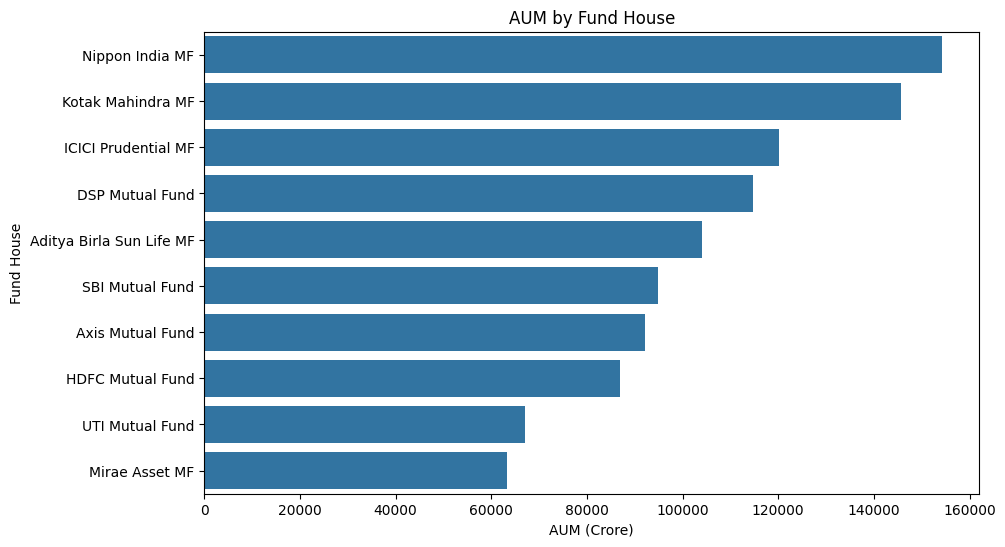

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.barplot(
    data=aum_by_house,
    x="aum_crore",
    y="fund_house"
)

plt.title("AUM by Fund House")
plt.xlabel("AUM (Crore)")
plt.ylabel("Fund House")

plt.show()

In [7]:
sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip_df.head())

print("\nColumns:")
print(sip_df.columns.tolist())

print("\nShape:")
print(sip_df.shape)

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  

Columns:
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Shape:
(48, 6)


In [8]:
sip_df["month"] = pd.to_datetime(sip_df["month"])

print(
    sip_df.loc[
        sip_df["sip_inflow_crore"].idxmax()
    ]
)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [9]:
import plotly.express as px

fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022-2025)"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High ₹31,002 Cr",
    showarrow=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Crore)"
)

fig.show()

In [10]:
cat_df = pd.read_csv("../data/raw/05_category_inflows.csv")

print(cat_df.head())

print("\nColumns:")
print(cat_df.columns.tolist())

print("\nShape:")
print(cat_df.shape)

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0

Columns:
['month', 'category', 'net_inflow_crore']

Shape:
(144, 3)


In [11]:
cat_df["month"] = pd.to_datetime(cat_df["month"])

heatmap_data = cat_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

print(heatmap_data.shape)
heatmap_data.head()

(12, 12)


month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


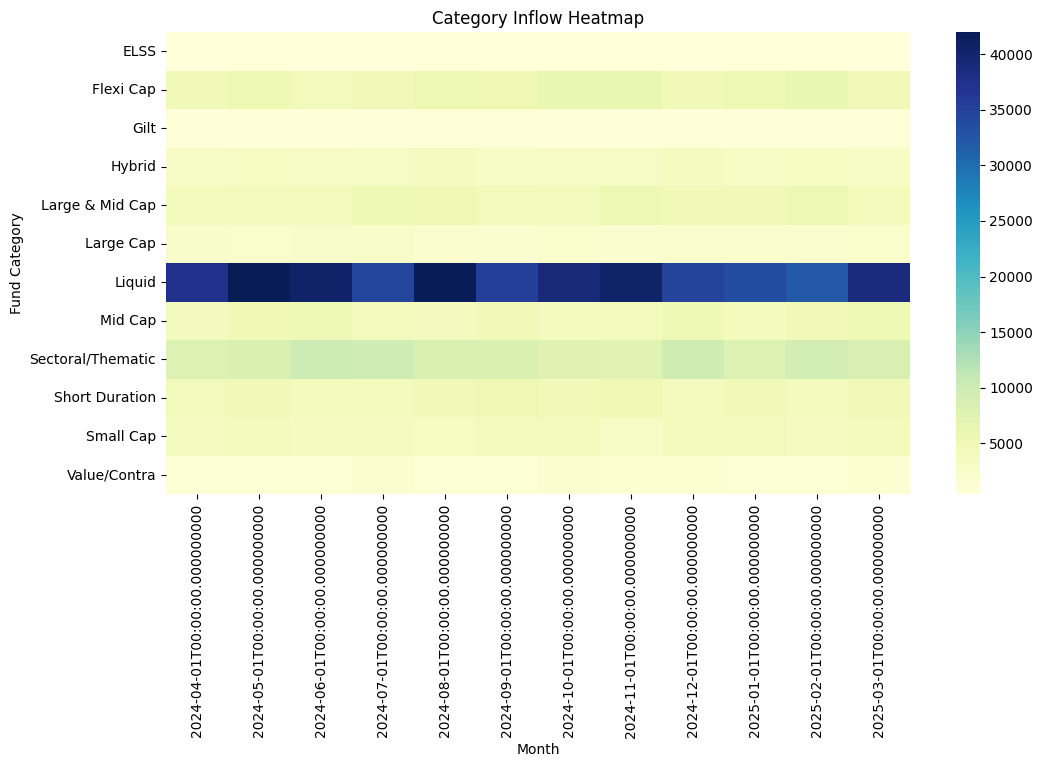

In [12]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

In [13]:
txn_df = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

print(txn_df["age_group"].value_counts())

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


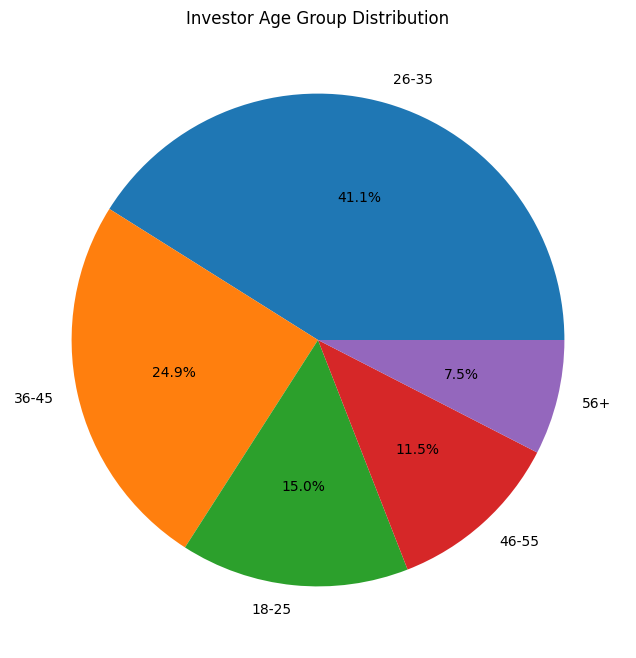

In [14]:
plt.figure(figsize=(8, 8))

txn_df["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.show()

In [15]:
print(txn_df["gender"].value_counts())

gender
Male      21809
Female    10969
Name: count, dtype: int64


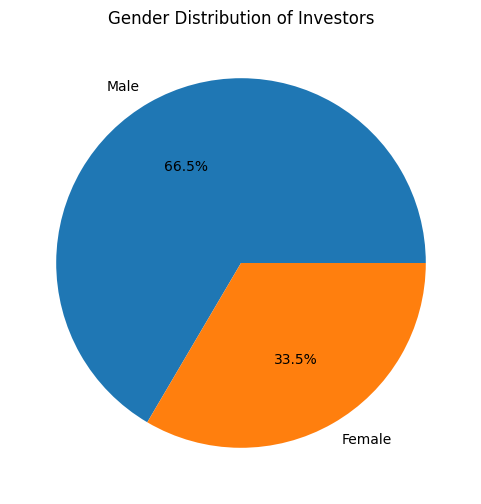

In [16]:
plt.figure(figsize=(6, 6))

txn_df["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution of Investors")
plt.ylabel("")

plt.show()

In [17]:
txn_df.groupby("age_group")["amount_inr"].describe()

,count,mean,std,min,25%,50%,75%,max
age_group,,,,,,,,
18-25,4916.0,108144.709520,151765.866810,401.0,3038.75,17553.0,190858.0,590635.0
26-35,13463.0,107821.452722,150251.623816,400.0,3151.50,18523.0,190901.5,597498.0
36-45,8146.0,107003.133808,150402.614486,400.0,3170.00,17457.0,188750.0,591658.0
46-55,3779.0,107278.769251,150601.035638,400.0,3144.00,17425.0,188516.5,587530.0
56+,2474.0,105613.105497,148465.191753,406.0,3302.50,20396.5,179326.5,587757.0


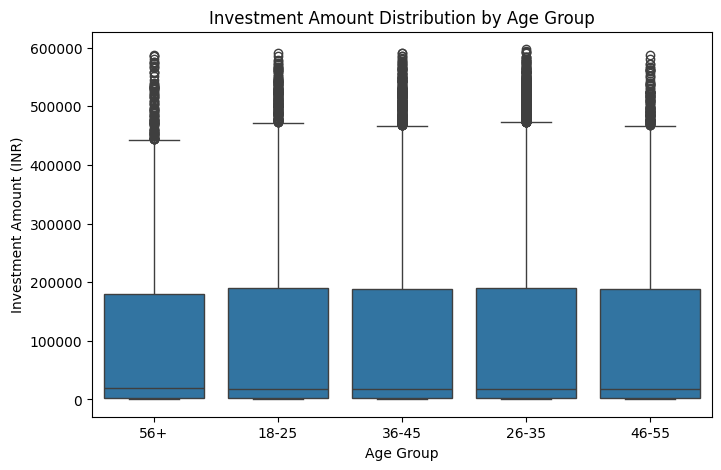

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=txn_df,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.show()

In [19]:
state_data = (
    txn_df.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(state_data.head(10))

            state  amount_inr
0          Punjab   315780459
1      Tamil Nadu   315177237
2  Madhya Pradesh   308312493
3       Rajasthan   298645822
4         Gujarat   298358940
5     West Bengal   297182514
6       Telangana   290219284
7           Delhi   289633404
8   Uttar Pradesh   285368873
9         Haryana   279634354


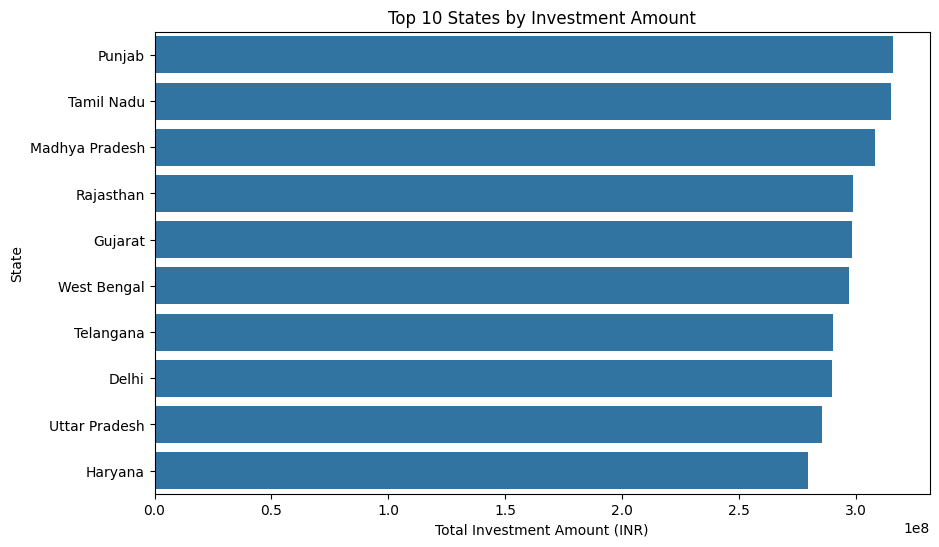

In [20]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=state_data.head(10),
    x="amount_inr",
    y="state"
)

plt.title("Top 10 States by Investment Amount")
plt.xlabel("Total Investment Amount (INR)")
plt.ylabel("State")

plt.show()

In [21]:
print(txn_df["city_tier"].value_counts())

city_tier
T30    21719
B30    11059
Name: count, dtype: int64


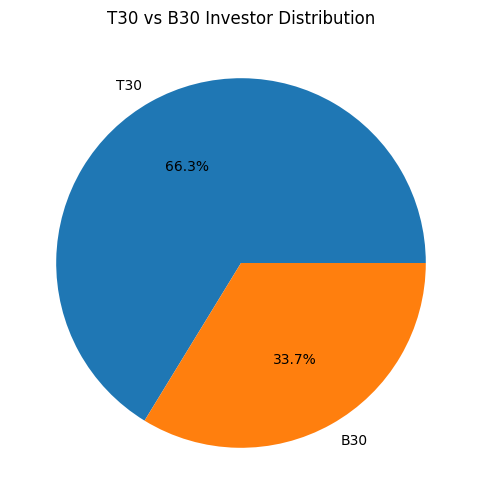

In [22]:
plt.figure(figsize=(6, 6))

txn_df["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")
plt.ylabel("")

plt.show()

In [23]:
folio_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio_df.head())

print("\nColumns:")
print(folio_df.columns.tolist())

print("\nShape:")
print(folio_df.shape)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  

Columns:
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

Shape:
(21, 6)


In [24]:
folio_df["month"] = pd.to_datetime(folio_df["month"])

print(
    "Start:",
    folio_df["total_folios_crore"].iloc[0]
)

print(
    "End:",
    folio_df["total_folios_crore"].iloc[-1]
)

Start: 13.26
End: 26.12


In [25]:
import plotly.express as px

fig = px.line(
    folio_df,
    x="month",
    y="total_folios_crore",
    title="Industry Folio Count Growth (2022-2025)"
)

fig.add_annotation(
    x=folio_df["month"].iloc[0],
    y=13.26,
    text="13.26 Cr",
    showarrow=True
)

fig.add_annotation(
    x=folio_df["month"].iloc[-1],
    y=26.12,
    text="26.12 Cr",
    showarrow=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)"
)

fig.show()

In [26]:
print(nav_df["amfi_code"].nunique())

print("\nFirst 10 AMFI Codes:")
print(nav_df["amfi_code"].unique()[:10])

40

First 10 AMFI Codes:
[100016 100025 100033 101206 101207 101208 102885 102886 102887 118632]


In [27]:
selected_codes = nav_df["amfi_code"].unique()[:10]

corr_df = nav_df[
    nav_df["amfi_code"].isin(selected_codes)
]

pivot_nav = corr_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

print(pivot_nav.shape)
pivot_nav.head()

(1150, 10)


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [28]:
correlation_matrix = pivot_nav.corr()

print(correlation_matrix.round(2))

amfi_code  100016  100025  100033  101206  101207  101208  102885  102886  \
amfi_code                                                                   
100016       1.00    0.59    0.65    0.57    0.64    0.72    0.69    0.55   
100025       0.59    1.00    0.91    0.91    0.57    0.95    0.95    0.45   
100033       0.65    0.91    1.00    0.95    0.59    0.97    0.94    0.54   
101206       0.57    0.91    0.95    1.00    0.44    0.93    0.94    0.37   
101207       0.64    0.57    0.59    0.44    1.00    0.69    0.60    0.71   
101208       0.72    0.95    0.97    0.93    0.69    1.00    0.98    0.56   
102885       0.69    0.95    0.94    0.94    0.60    0.98    1.00    0.47   
102886       0.55    0.45    0.54    0.37    0.71    0.56    0.47    1.00   
102887       0.60    0.96    0.90    0.91    0.54    0.93    0.94    0.52   
118632       0.69    0.93    0.92    0.92    0.57    0.95    0.96    0.41   

amfi_code  102887  118632  
amfi_code                  
100016       0.60  

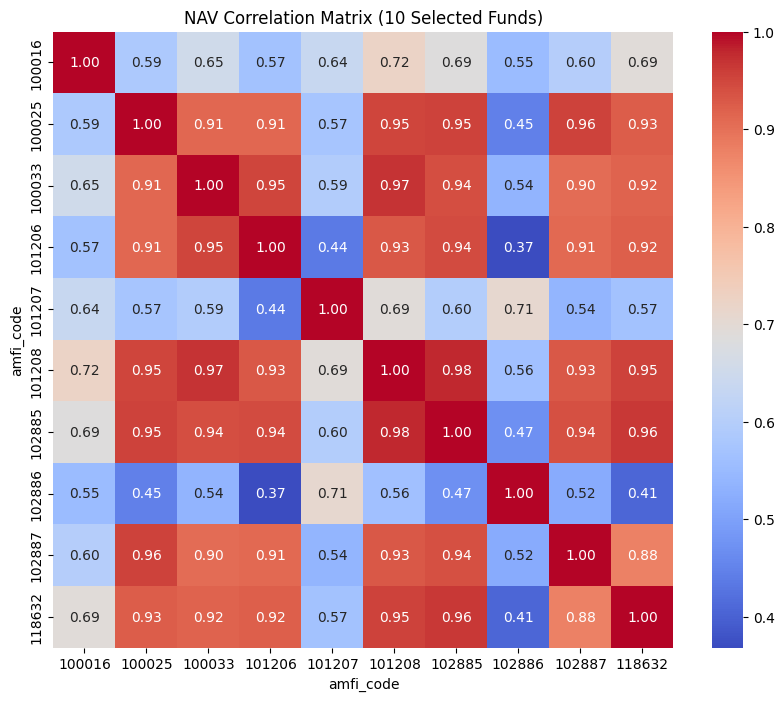

In [29]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Correlation Matrix (10 Selected Funds)")

plt.show()

In [30]:
portfolio_df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(portfolio_df.head())

print("\nColumns:")
print(portfolio_df.columns.tolist())

print("\nShape:")
print(portfolio_df.shape)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Shape:
(322, 8)


In [31]:
sector_data = (
    portfolio_df.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(sector_data.head(15))

            sector  weight_pct
0          Banking      652.26
1               IT      455.47
2           Pharma      407.45
3       Automobile      323.65
4        Utilities      265.54
5             FMCG      229.11
6   Infrastructure      192.16
7      Diversified      169.23
8          Telecom      145.62
9   Consumer Goods      127.61
10            NBFC      119.09
11          Energy      117.91
12          Cement      105.03
13          Paints       89.86


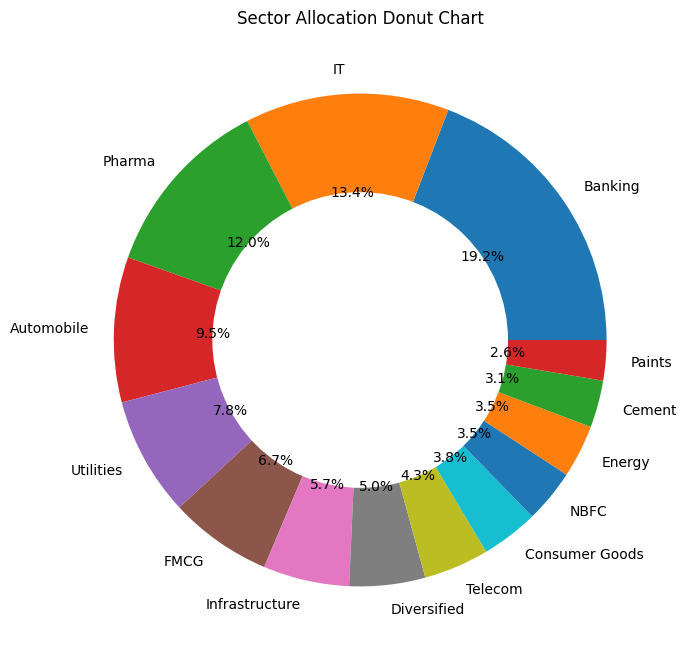

In [32]:
plt.figure(figsize=(8, 8))

plt.pie(
    sector_data["weight_pct"],
    labels=sector_data["sector"],
    autopct="%1.1f%%"
)

centre_circle = plt.Circle((0, 0), 0.60, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Donut Chart")

plt.show()

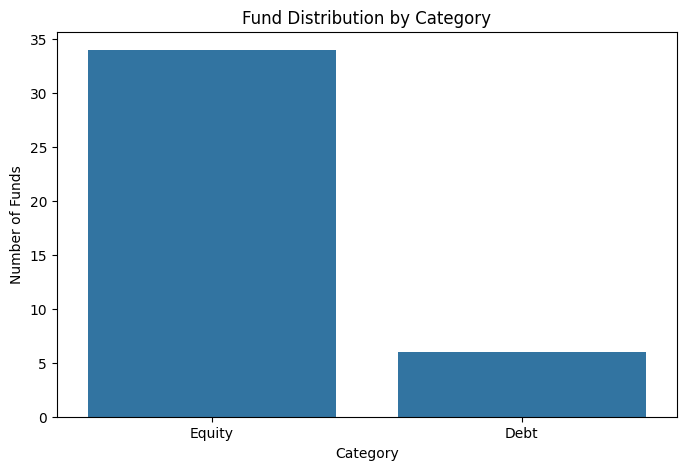

In [33]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

plt.figure(figsize=(8,5))

sns.countplot(
    data=fund_master,
    x="category"
)

plt.title("Fund Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Number of Funds")

plt.show()

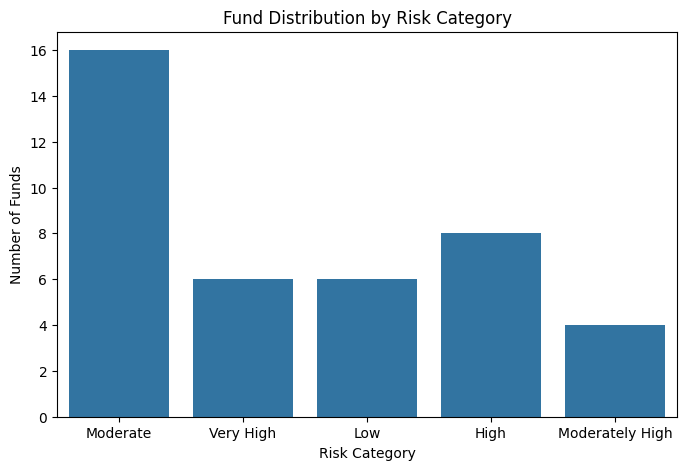

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fund_master,
    x="risk_category"
)

plt.title("Fund Distribution by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Funds")

plt.show()

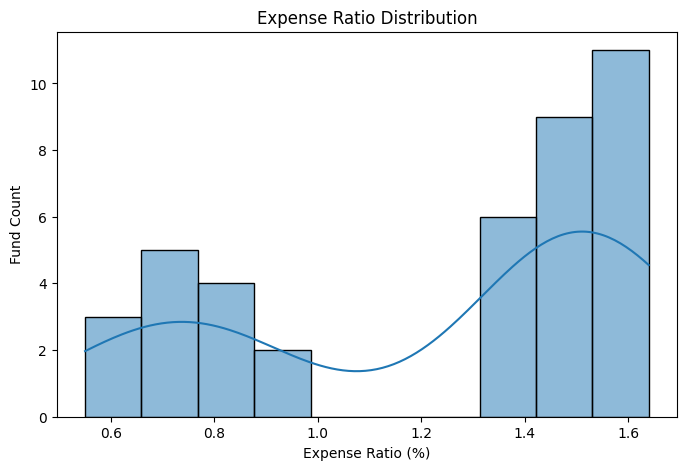

In [35]:
perf_df = pd.read_csv("../data/raw/07_scheme_performance.csv")

plt.figure(figsize=(8,5))

sns.histplot(
    perf_df["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Fund Count")

plt.show()

# Key EDA Findings

1. Average NAV increased consistently from 2022 to 2026, indicating long-term growth in mutual fund performance.

2. NAV growth accelerated during 2023, reflecting a strong market bull run.

3. Monthly SIP inflows reached an all-time high of ₹31,002 crore in December 2025.

4. Liquid funds consistently recorded the highest category inflows across most months.

5. The 26–35 age group contributes the largest share of investors (~41%).

6. Male investors account for approximately 66.5% of total investor participation.

7. Investment amount distributions are similar across age groups, though all groups contain high-value outliers.

8. T30 cities contribute approximately 66% of investor activity, indicating higher participation from major urban centers.

9. Industry folio count nearly doubled from 13.26 crore to 26.12 crore between 2022 and 2025.

10. Banking, IT, and Pharma are the dominant sectors in portfolio allocations, while most funds show strong positive correlations with one another.